In [5]:
import pandas as pd 
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
excel_file = pd.ExcelFile("../data/online_retail_II.xlsx")
excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

### Görev1.1: Online Retail II excelindeki 2010-2011 verisini okuyunuz. Oluşturduğunuz dataframe’in kopyasını oluşturunuz.

In [7]:
df_ = pd.read_excel("../data/online_retail_II.xlsx", sheet_name="Year 2010-2011")

df = df_.copy()
# df.head()

### Görev1.2: Veri setinin betimsel istatistiklerini inceleyiniz.

In [8]:
df.shape

(541910, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541910.0,9.552234,-80995.0,1.0,3.0,10.0,80995.0,218.080957
InvoiceDate,541910,2011-07-04 13:35:22.342307584,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
Price,541910.0,4.611138,-11062.06,1.25,2.08,4.13,38970.0,96.759765
Customer ID,406830.0,15287.68416,12346.0,13953.0,15152.0,16791.0,18287.0,1713.603074


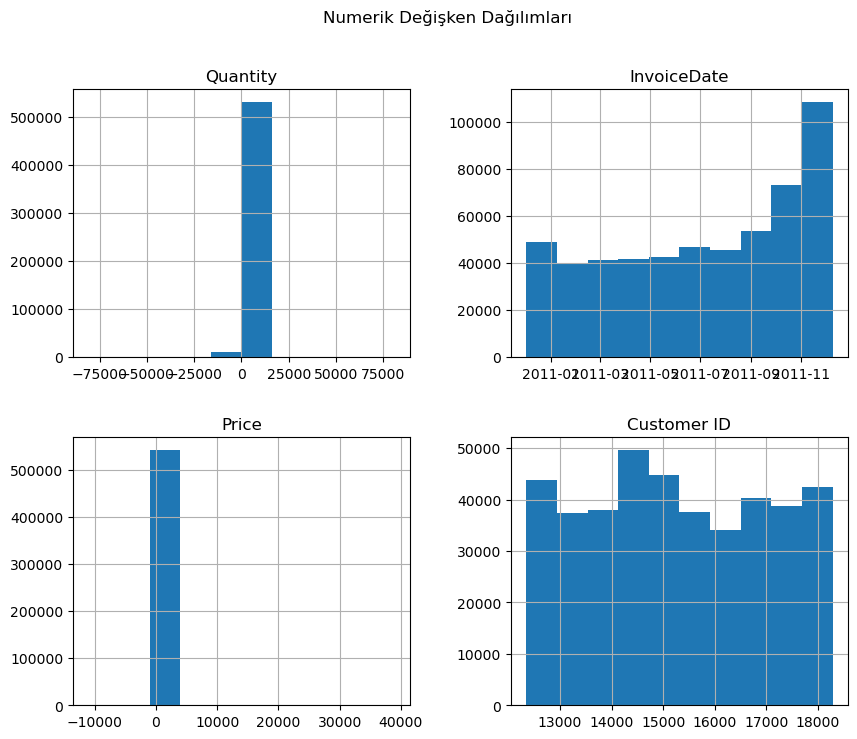

In [11]:
df.hist(figsize=(10,8))
plt.suptitle("Numerik Değişken Dağılımları")
plt.show()

### Görev1.3: Veri setinde eksik gözlem var mı? Varsa hangi değişkende kaç tane eksik gözlem vardır?

In [12]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

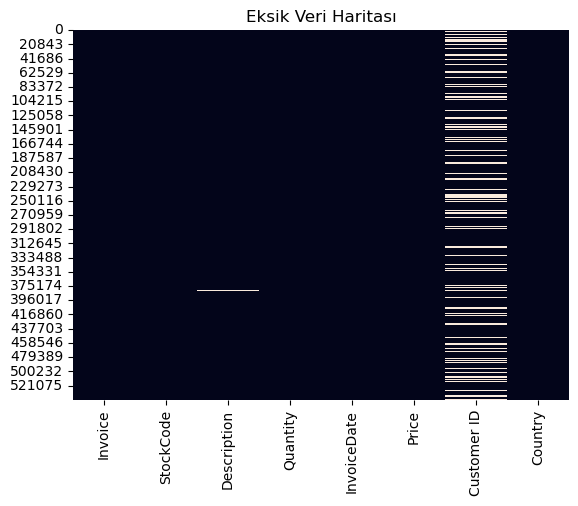

In [13]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Eksik Veri Haritası")
plt.show()

### Görev1.4: Eksik gözlemleri veri setinden çıkartınız. Çıkarma işleminde ‘inplace=True’ parametresini kullanınız.

In [14]:
df.dropna(inplace=True)
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

### Görev1.5: Eşsiz ürün sayısı kaçtır?

In [15]:
df["Description"].nunique()

3896

### Görev1.6: Hangi üründen kaçar tane vardır?

In [16]:
df["Description"].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2070
REGENCY CAKESTAND 3 TIER               1905
JUMBO BAG RED RETROSPOT                1662
ASSORTED COLOUR BIRD ORNAMENT          1418
PARTY BUNTING                          1416
                                       ... 
CROCHET LILAC/RED BEAR KEYRING            1
AMBER GLASS/SHELL/PEARL NECKLACE          1
5 STRAND GLASS NECKLACE AMETHYST          1
SILVER AND BLACK ORBIT NECKLACE           1
MIDNIGHT BLUE CRYSTAL DROP EARRINGS       1
Name: count, Length: 3896, dtype: int64

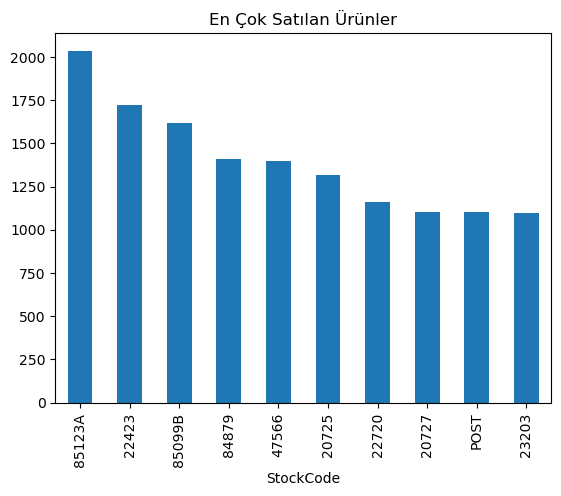

In [35]:
df["StockCode"].value_counts().head(10).plot(kind="bar")
plt.title("En Çok Satılan Ürünler")
plt.show()

### Görev1.7: En çok sipariş edilen 5 ürünü çoktan aza doğru sıralayınız.

In [17]:
df["Description"].value_counts().head(5)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2070
REGENCY CAKESTAND 3 TIER              1905
JUMBO BAG RED RETROSPOT               1662
ASSORTED COLOUR BIRD ORNAMENT         1418
PARTY BUNTING                         1416
Name: count, dtype: int64

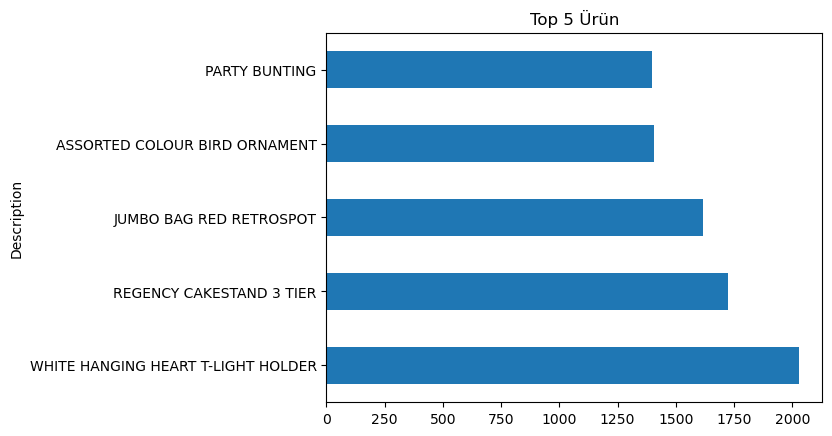

In [36]:
df["Description"].value_counts().head(5).plot(kind="barh")
plt.title("Top 5 Ürün")
plt.show()

### Görev1.8: Faturalardaki ‘C’ iptal edilen işlemleri göstermektedir. İptal edilen işlemleri veri setinden çıkartınız.

In [18]:
df = df[~df["Invoice"].astype(str).str.contains("C", na=False)]

### Görev1.9: Fatura başına elde edilen toplam kazancı ifade eden ‘TotalPrice’ adında bir değişken oluşturunuz.

In [19]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [20]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


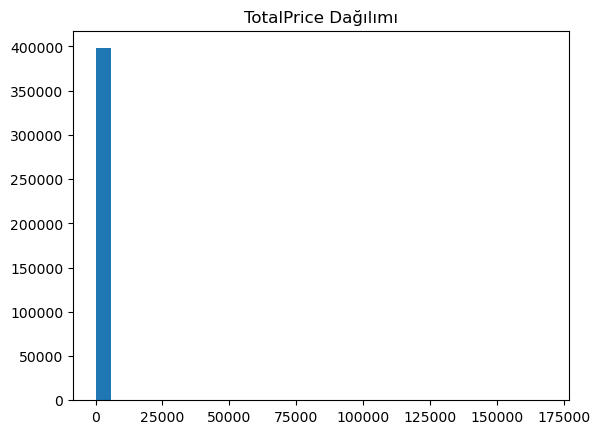

In [38]:
plt.hist(df["TotalPrice"], bins=30)
plt.title("TotalPrice Dağılımı")
plt.show()

### Görev2: RFM metriklerinin hesaplanması

In [21]:
today_date = dt.datetime(2011, 12, 11)

In [22]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (today_date - x.max()).days,
    "Invoice": lambda x: x.nunique(),
    "TotalPrice": lambda x: x.sum()
})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
Customer ID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [23]:
rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [24]:
rfm = rfm[rfm["monetary"] > 0]
rfm.head()

,recency,frequency,monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


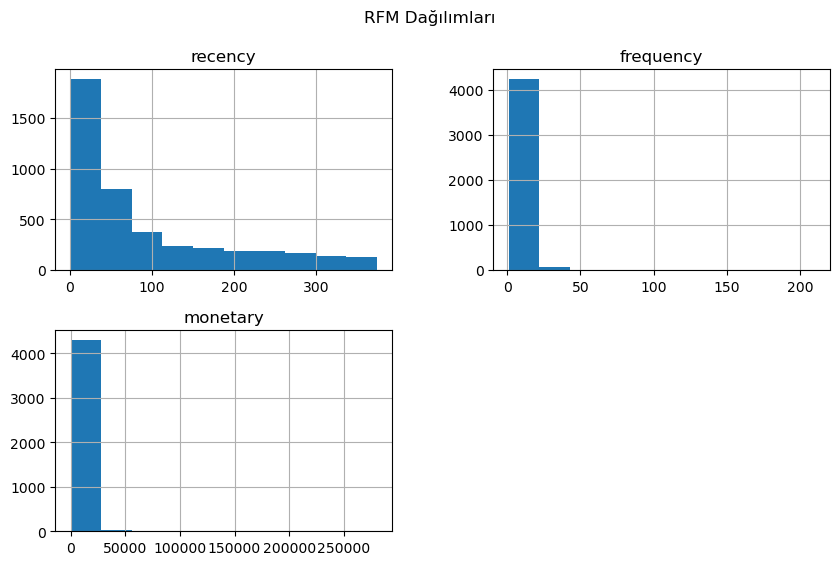

In [39]:
rfm.hist(figsize=(10,6))
plt.suptitle("RFM Dağılımları")
plt.show()

### Görev3: RFM skorlarının oluşturulması ve tek bir değişkene çevrilmesi

In [25]:
rfm["recency_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

In [26]:
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [27]:
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [28]:
rfm["RFM_SCORE"] = (
    rfm["recency_score"].astype(str) + rfm["frequency_score"].astype(str)
)

In [29]:
rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,326,1,77183.60,1,1,5,11
12347.0,3,7,4310.00,5,5,5,55
12348.0,76,4,1797.24,2,4,4,24
12349.0,19,1,1757.55,4,1,4,41
12350.0,311,1,334.40,1,1,2,11


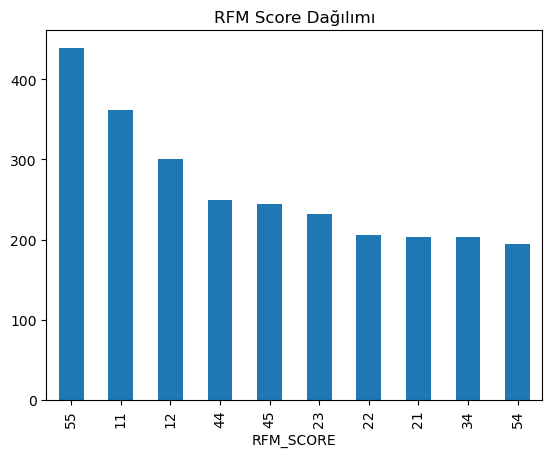

In [40]:
rfm["RFM_SCORE"].value_counts().head(10).plot(kind="bar")
plt.title("RFM Score Dağılımı")
plt.show()

### Görev4: RFM skorlarının segment olarak tanımlanması

In [30]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

In [31]:
rfm["segment"] = rfm["RFM_SCORE"].replace(
    seg_map,
    regex=True
)

In [32]:
rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
Customer ID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,11,hibernating
12347.0,3,7,4310.00,5,5,5,55,champions
12348.0,76,4,1797.24,2,4,4,24,at_risk
12349.0,19,1,1757.55,4,1,4,41,promising
12350.0,311,1,334.40,1,1,2,11,hibernating


In [33]:
rfm.groupby("segment").agg({
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
})

,recency,frequency,monetary
segment,,,
about_to_sleep,53.312500,1.161932,471.994375
at_risk,153.785835,2.878583,1084.535297
cant_loose,132.968254,8.380952,2796.155873
champions,6.361769,12.417062,6857.963918
hibernating,217.605042,1.101774,488.643307
loyal_customers,33.608059,6.479853,2864.247791
need_attention,52.427807,2.326203,897.627861
new_customers,7.428571,1.000000,388.212857
potential_loyalists,17.398760,2.010331,1041.222004


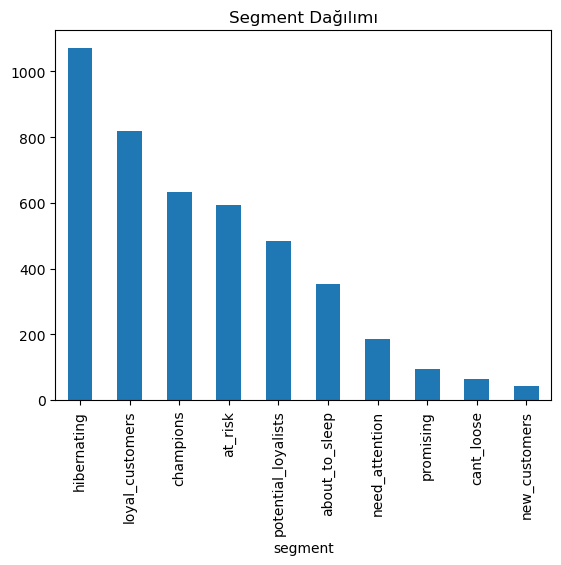

In [41]:
rfm["segment"].value_counts().plot(kind="bar")
plt.title("Segment Dağılımı")
plt.show()

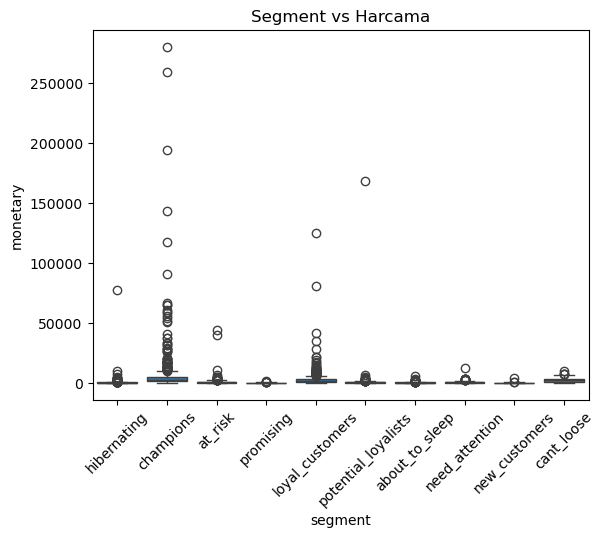

In [42]:
sns.boxplot(x="segment", y="monetary", data=rfm)
plt.xticks(rotation=45)
plt.title("Segment vs Harcama")
plt.show()

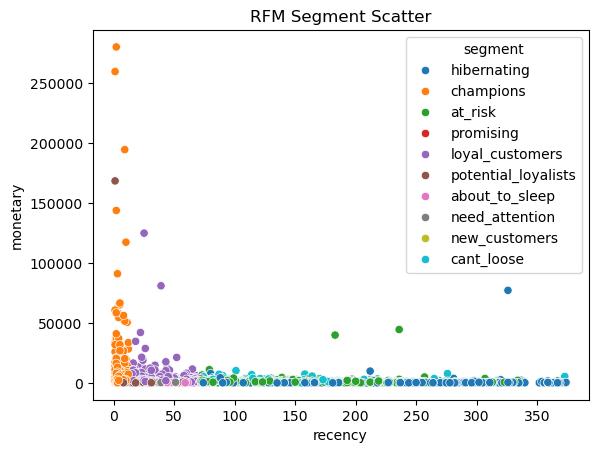

In [43]:
sns.scatterplot(x="recency", y="monetary", hue="segment", data=rfm)
plt.title("RFM Segment Scatter")
plt.show()

### Görev5: Aksiyon zamanı!

In [34]:
loyal_df = rfm[rfm["segment"] == "loyal_customers"]

loyal_df.to_excel("../outputs/loyal_customers.xlsx")